# PS1: Growth, and where linear theory dies

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github.com/shadaba/ictp-cosmology-lss-lectures/blob/main/notebooks/P1_growth_nonlinear.ipynb)

In [1]:
# In a local clone this finds it in the repo root (one level up).
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import lsscosmo as lc
print('lsscosmo loaded from', lc.__file__)


lsscosmo loaded from /Users/shadab/Documents/Projects/ictp-cosmology-lss-lectures/notebooks/lsscosmo.py



**Problem Set 1**

Locate the scale where linear theory stops being trustworthy.

The linear growth factor $D(z)$ and rate $f(z)=\mathrm{d}\ln D/\mathrm{d}\ln a$
follow from
$$ \ddot{\delta} + 2H\dot{\delta} - 4\pi G \bar{\rho}_m\,\delta = 0 . $$
The dimensionless power $\Delta^2(k)=k^3 P(k)/2\pi^2$ is the variance of the
density field per logarithmic interval in $k$; the nonlinear scale $k_{\rm nl}$
is where $\Delta^2(k_{\rm nl}) \simeq 1$.

**Task:** the two plots produced below, the value of $k_{\rm nl}$ at
$z=0$ and $z=1$, 


In [10]:
# Two cosmologies: the fiducial, and one with lower matter density.
cosmo_fid = lc.Cosmology(Om=0.3153)
cosmo_low = lc.Cosmology(Om=0.25)
cosmo_high = lc.Cosmology(Om=0.35)
z = np.linspace(0.0, 3.0, 31)
print('fiducial Om =', cosmo_fid.Om, '   comparison Om =', cosmo_low.Om)
# quick sanity check of the machinery you will use:
print('D(0) =', round(float(cosmo_fid.growth_factor(0.0)), 3),
      '  D(1) =', round(float(cosmo_fid.growth_factor(1.0)), 3),
      '  f(0) =', round(float(cosmo_fid.growth_rate(0.0)), 3))

fiducial Om = 0.3153    comparison Om = 0.25
D(0) = 1.0   D(1) = 0.607   f(0) = 0.527


### Task 1. Growth rate $f(z)$ for two cosmologies
Compute $f(z)$ for both cosmologies with `cosmo.growth_rate(z)` (it accepts the
whole `z` array at once) and plot them together.

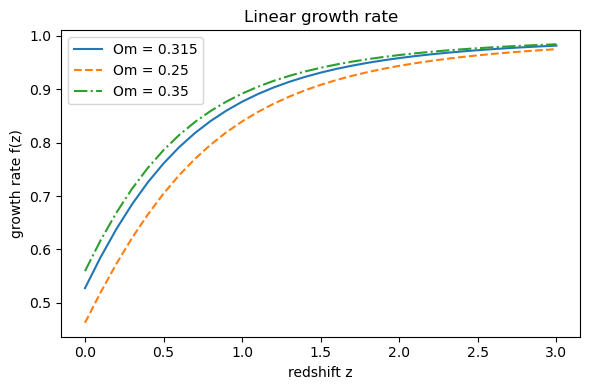

f(0), fiducial = 0.5274


In [11]:
f_fid = cosmo_fid.growth_rate(z)
f_low = cosmo_low.growth_rate(z)
f_high = cosmo_high.growth_rate(z)
plt.figure(figsize=(6, 4))
plt.plot(z, f_fid,'-', label='Om = 0.315')
plt.plot(z, f_low,'--', label='Om = 0.25')
plt.plot(z, f_high,'-.', label='Om = 0.35')
plt.xlabel('redshift z'); plt.ylabel('growth rate f(z)')
plt.legend(); plt.title('Linear growth rate'); plt.tight_layout(); plt.show()
print('f(0), fiducial =', round(float(cosmo_fid.growth_rate(0.0)), 4))

### Task 2. The dimensionless power and the nonlinear scale
Build $\Delta^2(k)=k^3 P(k)/2\pi^2$ at $z=0$ and $z=1$ (fiducial cosmology,
`power_spectrum_nowiggle`), plot on log-log axes, and read off $k_{\rm nl}$
where $\Delta^2=1$.

z = 0 :  k_nl = 0.250 h/Mpc
z = 1 :  k_nl = 0.785 h/Mpc
z = 3 :  k_nl = nan h/Mpc


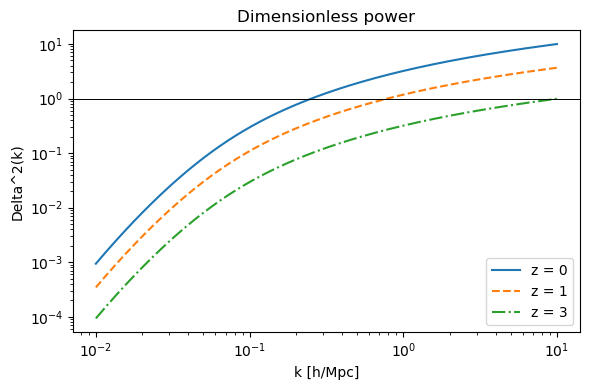

In [12]:
k = np.logspace(-2, 1, 400)
plt.figure(figsize=(6, 4))
for zz, ls in [(0.0, '-'), (1.0, '--'),(3.0,'-.')]:
    Pk = cosmo_fid.power_spectrum_nowiggle(k, zz)
    D2 = k**3 * Pk / (2 * np.pi**2)
    plt.loglog(k, D2, ls, label='z = %.0f' % zz)
    cross = np.where(np.diff(np.sign(D2 - 1.0)))[0]
    knl = k[cross[0]] if len(cross) else np.nan
    print('z = %.0f :  k_nl = %.3f h/Mpc' % (zz, knl))
plt.axhline(1.0, color='k', lw=0.7)
plt.xlabel('k [h/Mpc]'); plt.ylabel('Delta^2(k)')
plt.legend(); plt.title('Dimensionless power'); plt.tight_layout(); plt.show()

### Your answer (write here)
**(1) At what scale would you trust linear theory for a survey at
$z=1$, and why?**

**(2) At low why growth should be sensitive to dark energy?**